In [1]:
from pathlib import Path

DATA_DIR = Path("../data/raw/Bali/letter")

classes = sorted([folder for folder in DATA_DIR.iterdir() if folder.is_dir()])

for folder in classes:
    images = list(folder.glob("*"))
    print(f"{folder.name}: {len(images)}")

print("total classes:", len(classes))

ba: 248
ca: 251
da: 246
ga: 246
ha: 250
ja: 251
ka: 250
la: 250
ma: 250
na: 252
nga: 250
nya: 251
pa: 248
ra: 252
sa: 249
ta: 250
wa: 249
ya: 250
total classes: 18


In [2]:
from PIL import Image

corrupted = []

for folder in classes:
    for image_path in folder.iterdir():
        try:
            with Image.open(image_path) as img:
                img.verify()
        except Exception:
            corrupted.append(str(image_path))

print("corrupted files:", len(corrupted))

corrupted files: 0


In [3]:
sizes = set()

for folder in classes:
    for image_path in folder.iterdir():
        with Image.open(image_path) as img:
            sizes.add(img.size)

print("unique image sizes:", len(sizes))
print(sorted(sizes))

unique image sizes: 3314
[(72, 77), (89, 78), (94, 78), (94, 90), (98, 101), (99, 90), (100, 84), (100, 87), (102, 97), (102, 111), (103, 95), (104, 83), (104, 102), (106, 75), (107, 91), (108, 83), (108, 103), (108, 104), (110, 107), (110, 111), (112, 81), (112, 98), (113, 72), (113, 95), (113, 104), (113, 106), (114, 107), (115, 106), (116, 96), (116, 102), (116, 104), (116, 128), (116, 130), (117, 96), (117, 110), (117, 112), (117, 135), (117, 140), (118, 69), (118, 91), (118, 97), (118, 108), (118, 111), (118, 136), (119, 101), (119, 104), (119, 111), (120, 110), (121, 108), (121, 119), (122, 90), (122, 93), (123, 82), (123, 98), (123, 104), (125, 74), (125, 100), (125, 113), (126, 81), (126, 86), (126, 92), (126, 114), (126, 134), (126, 159), (127, 69), (127, 77), (127, 96), (127, 101), (127, 123), (127, 133), (128, 104), (128, 108), (128, 109), (128, 120), (128, 121), (128, 133), (130, 102), (130, 106), (130, 139), (131, 103), (131, 112), (131, 114), (131, 120), (131, 132), (131,

In [4]:
# sebelum menentukan split, kita perlu tahu apakah filename menyimpan informasi writer/orang yang menulis.
for folder in classes[:3]:
    print(f"\n{folder.name}:")
    for image_path in list(folder.iterdir())[:10]:
        print(image_path.name)


ba:
Ba_238.jpg
Ba_210.jpg
Ba_204.jpg
Ba_24.jpg
Ba_30.jpg
Ba_18.jpg
Ba_166.jpg
Ba_172.jpg
Ba_199.jpg
Ba_198.jpg

ca:
Ca_238.jpg
Ca_35.jpg
Ca_21.jpg
Ca_204.jpg
Ca_210.jpg
Ca_172.jpg
Ca_166.jpg
Ca_199.jpg
Ca_198.jpg
Ca_167.jpg

da:
Da_249.jpg
Da_75.jpg
Da_61.jpg
Da_49.jpg
Da_2.jpg
Da_103.jpg
Da_117.jpg
Da_116.jpg
Da_102.jpg
Da_3.jpg


In [5]:
# cek apakah id yang sama memang muncul lintas banyak class
from collections import defaultdict

writer_classes = defaultdict(set)

for folder in classes:
    for image_path in folder.iterdir():
        writer_id = image_path.stem.split("_")[-1]
        writer_classes[writer_id].add(folder.name)

for writer_id in sorted(writer_classes, key=lambda x: int(x))[:20]:
    print(writer_id, len(writer_classes[writer_id]), sorted(writer_classes[writer_id]))

1 18 ['ba', 'ca', 'da', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'wa', 'ya']
2 18 ['ba', 'ca', 'da', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'wa', 'ya']
3 18 ['ba', 'ca', 'da', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'wa', 'ya']
4 18 ['ba', 'ca', 'da', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'wa', 'ya']
5 18 ['ba', 'ca', 'da', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'wa', 'ya']
6 18 ['ba', 'ca', 'da', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'wa', 'ya']
7 18 ['ba', 'ca', 'da', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'wa', 'ya']
8 18 ['ba', 'ca', 'da', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'wa', 'ya']
9 18 ['ba', 'ca', 'da', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga',

In [6]:
# cek total writer + completeness
all_writer_ids = sorted(writer_classes.keys(), key=int)

complete_writers = [
    writer_id
    for writer_id, cls_set in writer_classes.items()
    if len(cls_set) == 18
]

incomplete_writers = {
    writer_id: sorted(cls_set)
    for writer_id, cls_set in writer_classes.items()
    if len(cls_set) != 18
}

print("total writers:", len(all_writer_ids))
print("complete writers:", len(complete_writers))
print("incomplete writers:", len(incomplete_writers))

if incomplete_writers:
    print("\nincomplete writer details:")
    for writer_id, cls_set in incomplete_writers.items():
        print(writer_id, len(cls_set), cls_set)

total writers: 252
complete writers: 243
incomplete writers: 9

incomplete writer details:
248 17 ['ba', 'ca', 'da', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'wa', 'ya']
67 17 ['ba', 'ca', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'wa', 'ya']
247 17 ['ba', 'ca', 'da', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'wa', 'ya']
64 17 ['ba', 'ca', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'wa', 'ya']
88 17 ['ba', 'ca', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'ra', 'sa', 'ta', 'wa', 'ya']
249 15 ['ca', 'da', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'ra', 'sa', 'ta', 'wa', 'ya']
251 5 ['ca', 'ja', 'na', 'nya', 'ra']
250 12 ['ca', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'ra', 'ta', 'ya']
252 2 ['na', 'ra']


In [7]:
#cek metadata/readme dataset
from pathlib import Path

BALI_DIR = Path("../data/raw/Bali")

for path in BALI_DIR.rglob("*"):
    if path.is_file() and path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
        print(path)

../data/raw/Bali/.DS_Store
../data/raw/Bali/letter/.DS_Store


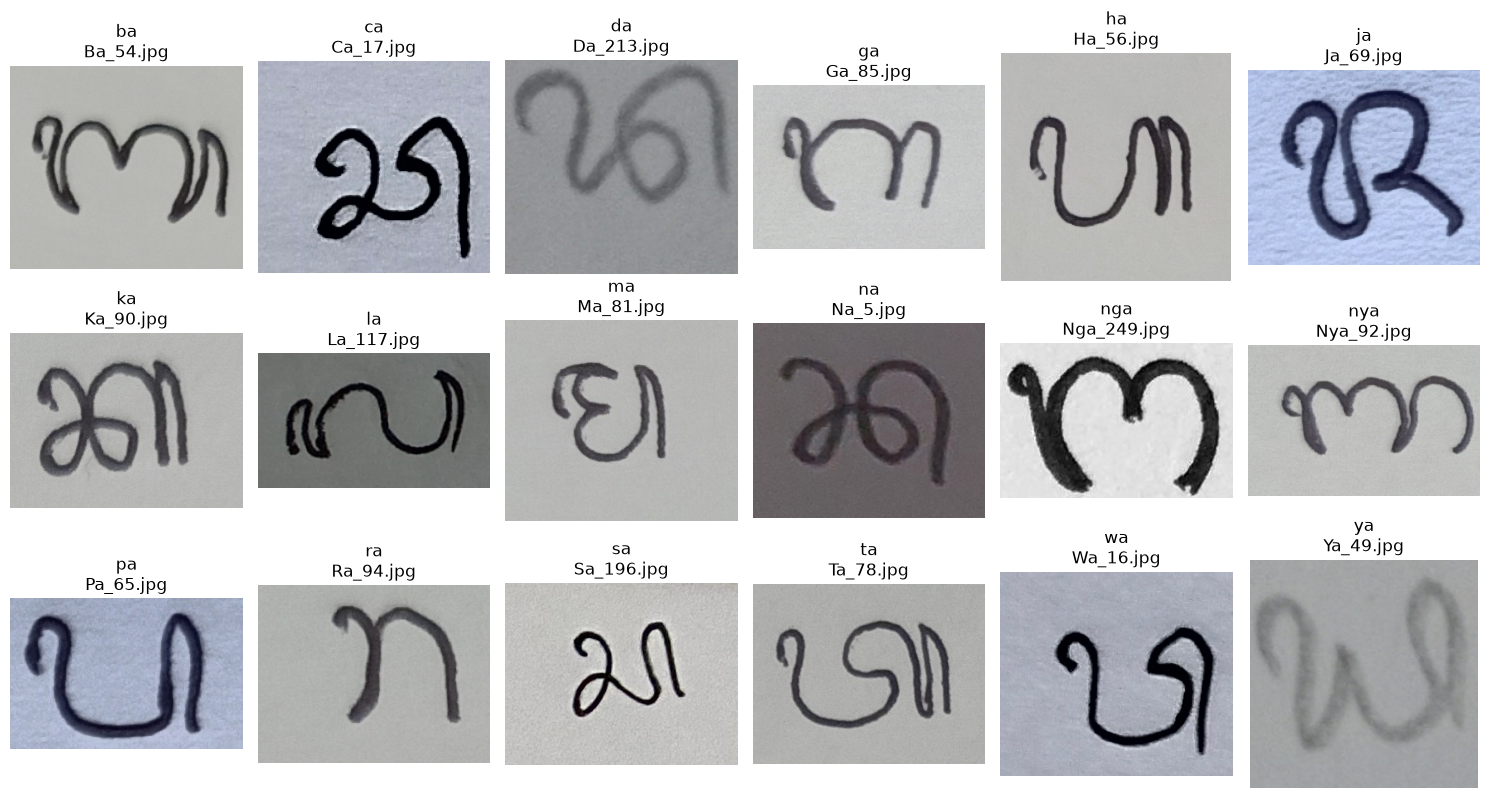

In [8]:
# lihat random sample dari tiap class
import random
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(3, 6, figsize=(15, 8))

for ax, folder in zip(axes.flatten(), classes):
    images = list(folder.iterdir())
    sample = random.choice(images)

    img = Image.open(sample)

    ax.imshow(img, cmap="gray")
    ax.set_title(f"{folder.name}\n{sample.name}")
    ax.axis("off")

plt.tight_layout()
plt.show()

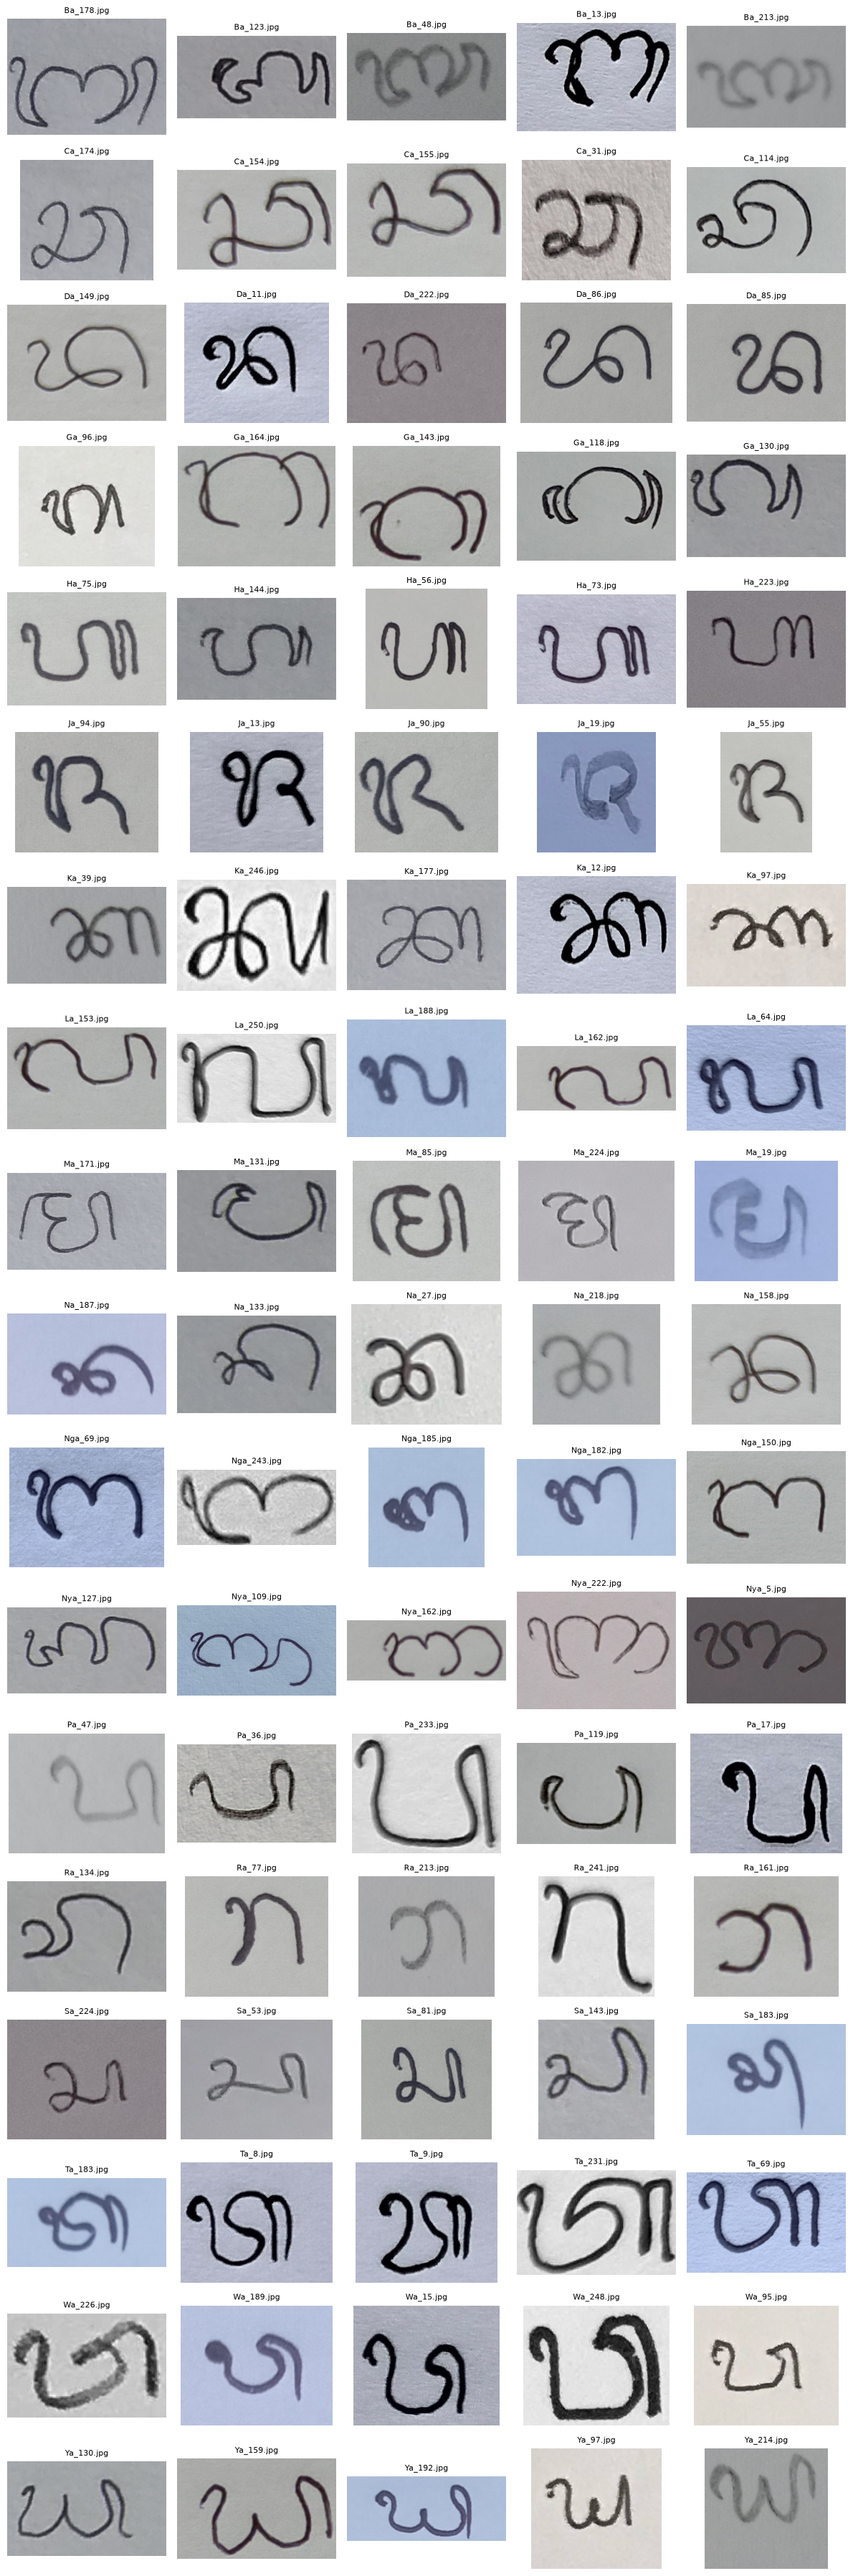

In [9]:
#audit lebih dari 1 gambar per class

samples_per_class = 5

fig, axes = plt.subplots(
    len(classes),
    samples_per_class,
    figsize=(12, 36)
)

for row, folder in enumerate(classes):
    images = list(folder.iterdir())
    samples = random.sample(images, samples_per_class)

    for col, sample in enumerate(samples):
        img = Image.open(sample)

        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(sample.name, fontsize=8)
        axes[row, col].axis("off")

    axes[row, 0].set_ylabel(
        folder.name,
        rotation=0,
        labelpad=25,
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [10]:
# generate final split
import random
import pandas as pd
from pathlib import Path

SEED = 42
random.seed(SEED)

# pisahkan group lengkap vs tidak lengkap
complete_ids = sorted(
    [wid for wid, cls_set in writer_classes.items() if len(cls_set) == 18],
    key=int
)

incomplete_ids = sorted(
    [wid for wid, cls_set in writer_classes.items() if len(cls_set) != 18],
    key=int
)

# shuffle secara reproducible
random.shuffle(complete_ids)

# 243 complete groups:
# 38 validation + 38 test + 167 train
val_ids = set(complete_ids[:38])
test_ids = set(complete_ids[38:76])
train_ids = set(complete_ids[76:]) | set(incomplete_ids)

# buat manifest untuk semua image
records = []

for folder in classes:
    for image_path in folder.iterdir():
        if not image_path.is_file() or image_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue

        group_id = image_path.stem.split("_")[-1]

        if group_id in train_ids:
            split = "train"
        elif group_id in val_ids:
            split = "validation"
        elif group_id in test_ids:
            split = "test"
        else:
            raise ValueError(f"group {group_id} tidak masuk split mana pun")

        records.append({
            "path": str(image_path),
            "label": folder.name,
            "group_id": group_id,
            "split": split
        })

df_split = pd.DataFrame(records)

# simpan
Path("../outputs").mkdir(exist_ok=True)
df_split.to_csv("../outputs/final_split.csv", index=False)

# summary
print(df_split["split"].value_counts())
print()
print("train groups:", len(train_ids))
print("validation groups:", len(val_ids))
print("test groups:", len(test_ids))
print()
print("total images:", len(df_split))

split
train         3125
validation     684
test           684
Name: count, dtype: int64

train groups: 176
validation groups: 38
test groups: 38

total images: 4493


In [11]:
# verify split integrity

# cek group leakage
train_groups = set(df_split[df_split["split"] == "train"]["group_id"])
val_groups = set(df_split[df_split["split"] == "validation"]["group_id"])
test_groups = set(df_split[df_split["split"] == "test"]["group_id"])

print("train ∩ validation:", len(train_groups & val_groups))
print("train ∩ test:", len(train_groups & test_groups))
print("validation ∩ test:", len(val_groups & test_groups))

print("\nimages per class per split:")
print(
    df_split.groupby(["label", "split"])
    .size()
    .unstack(fill_value=0)
)

train ∩ validation: 0
train ∩ test: 0
validation ∩ test: 0

images per class per split:
split  test  train  validation
label                         
ba       38    172          38
ca       38    175          38
da       38    170          38
ga       38    170          38
ha       38    174          38
ja       38    175          38
ka       38    174          38
la       38    174          38
ma       38    174          38
na       38    176          38
nga      38    174          38
nya      38    175          38
pa       38    172          38
ra       38    176          38
sa       38    173          38
ta       38    174          38
wa       38    173          38
ya       38    174          38


In [12]:
# cek exact duplicate

import hashlib
from collections import defaultdict

hash_records = defaultdict(list)

for _, row in df_split.iterrows():
    image_path = Path(row["path"])

    with open(image_path, "rb") as f:
        file_hash = hashlib.sha256(f.read()).hexdigest()

    hash_records[file_hash].append({
        "path": row["path"],
        "label": row["label"],
        "group_id": row["group_id"],
        "split": row["split"]
    })

duplicates = {
    h: records
    for h, records in hash_records.items()
    if len(records) > 1
}

cross_split_duplicates = {
    h: records
    for h, records in duplicates.items()
    if len({r["split"] for r in records}) > 1
}

print("duplicate groups:", len(duplicates))
print("cross-split duplicate groups:", len(cross_split_duplicates))

duplicate groups: 0
cross-split duplicate groups: 0


In [13]:
summary = {
    "total_images": len(df_split),
    "total_classes": df_split["label"].nunique(),
    "total_groups": df_split["group_id"].nunique(),

    "train_images": (df_split["split"] == "train").sum(),
    "validation_images": (df_split["split"] == "validation").sum(),
    "test_images": (df_split["split"] == "test").sum(),

    "train_groups": len(train_groups),
    "validation_groups": len(val_groups),
    "test_groups": len(test_groups),

    "group_leakage": 0,
    "cross_split_duplicates": 0,
    "random_seed": 42
}

pd.Series(summary)

total_images              4493
total_classes               18
total_groups               252
train_images              3125
validation_images          684
test_images                684
train_groups               176
validation_groups           38
test_groups                 38
group_leakage                0
cross_split_duplicates       0
random_seed                 42
dtype: int64